# Supervised Machine Learning Project
Prepared by: Dev Rijwani

# Student Performance Prediction : LinearRegression

In [ ]:
#did not find out that dataset that's why

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df = df.dropna()
df = df.drop_duplicates()


In [7]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["race/ethnicity"] = le.fit_transform(df["race/ethnicity"])
df["parental level of education"] = le.fit_transform(df["parental level of education"])
df["lunch"] = le.fit_transform(df["lunch"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])

In [14]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

In [18]:
y_pred

array([77.11855699, 57.07358   , 79.35766788, 77.15093246, 84.91283746,
       79.85882914, 64.42312794, 52.47379147, 74.61139924, 50.01079481,
       50.44499321, 34.35758768, 66.28655135, 53.66602689, 87.80646619,
       72.17082069, 53.95429413, 49.37064522, 50.9262122 , 54.29513402,
       76.62310917, 40.71538364, 58.29731054, 37.36725562, 79.81455128,
       82.97797069, 78.19297014, 47.74573476, 30.07261305, 50.78240619,
       64.87175577, 71.33702911, 60.67758836, 80.02527415, 81.33394066,
       44.34870972, 77.69510363, 71.30097175, 68.74385772,  5.55960328,
       79.39326779, 67.03153924, 70.24327126, 57.98869524, 81.84992687,
       63.32744767, 72.92197518, 25.23196669, 88.34098662, 68.57937392,
       74.78793329, 68.47641886, 81.93280101, 44.45521451, 66.816886  ,
       68.45481502, 87.85867411, 59.7048815 , 82.00776395, 79.76782416,
       46.22592721, 72.64647108, 71.08502792, 53.81716683, 89.61629394,
       65.04085968, 60.6108109 , 55.94870276, 57.79623104, 83.99

In [19]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8838026201112225


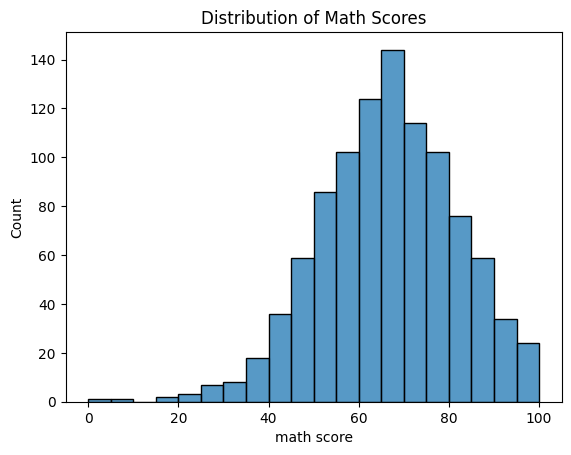

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["math score"], bins=20)
plt.title("Distribution of Math Scores")
plt.show()

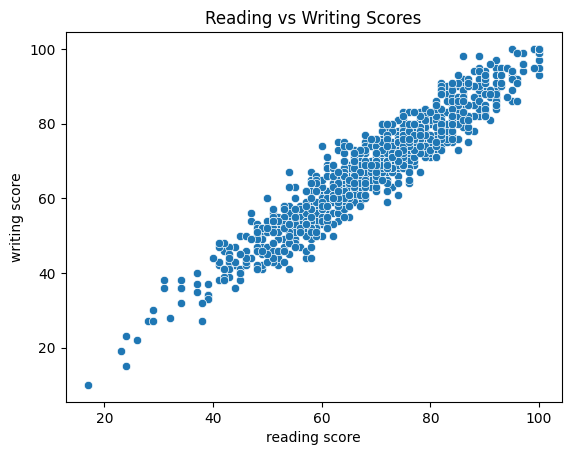

In [23]:
sns.scatterplot(x=df["reading score"], y=df["writing score"])
plt.title("Reading vs Writing Scores")
plt.show()

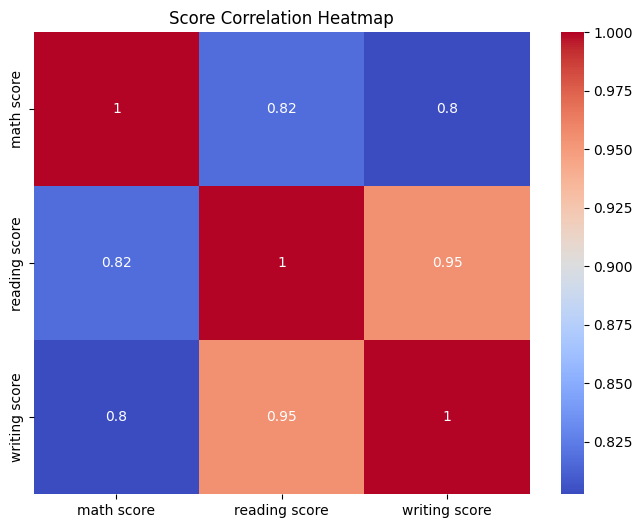

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["math score","reading score","writing score"]].corr(),annot=True,cmap="coolwarm")
plt.title("Score Correlation Heatmap")
plt.show()